# Automatic Structure for $F_2$

This notebook constructs and analyzes the reduced-word automaton for $F_2=\langle a,b\rangle$
with formal state set $\{e,v_1,v_2,v_3,v_4\}$, where
$v_1,v_2,v_3,v_4$ correspond to the "last generator" $a,a^{-1},b,b^{-1}$ respectively.

## Objectives
1. Build and visualize the automaton $\mathcal{G}$.
2. Build and visualize the component graph $C(\mathcal{G})$.
3. Compute $M$, $M_C$, PF data, the normalized matrix $N$, and the measure $\mu$.
4. Run helper diagnostics and ordered-frequency examples.

## Conventions
- Global state order: `['e', 'v_1', 'v_2', 'v_3', 'v_4']`.
- All matrices and vectors follow this order unless noted otherwise.


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Force static inline rendering (prevents scrollable/interactive figure widgets).
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')
plt.ioff()

# Display settings for readable notebook output.
np.set_printoptions(suppress=True, linewidth=140, precision=6)
plt.rcParams['figure.figsize'] = (8, 5)


Matplotlib is building the font cache; this may take a moment.


## 1) Build $\mathcal G$ (5-state automaton) and draw digraph

In [2]:
# --- Block 1: Define canonical state order and index map ---
states = ['e', 'v_1', 'v_2', 'v_3', 'v_4']
idx = {s: i for i, s in enumerate(states)}

# --- Block 2: Labeled reduced-word transitions ---
# v_1, v_2, v_3, v_4 correspond to a, A, b, B.
transitions = {
    'e': [('a', 'v_1'), ('A', 'v_2'), ('b', 'v_3'), ('B', 'v_4')],
    'v_1': [('a', 'v_1'), ('b', 'v_3'), ('B', 'v_4')],
    'v_2': [('A', 'v_2'), ('b', 'v_3'), ('B', 'v_4')],
    'v_3': [('a', 'v_1'), ('A', 'v_2'), ('b', 'v_3')],
    'v_4': [('a', 'v_1'), ('A', 'v_2'), ('B', 'v_4')],
}

# --- Block 3: Build directed graph with edge labels ---
G = nx.DiGraph()
G.add_nodes_from(states)
for u, outs in transitions.items():
    for gen, v in outs:
        G.add_edge(u, v, label=gen)

# --- Block 4: Build adjacency matrix M in canonical order ---
M = nx.to_numpy_array(G, nodelist=states, dtype=int)
print('States order:', states)
print('M shape:', M.shape)
print(M)


States order: ['e', 'v_1', 'v_2', 'v_3', 'v_4']
M shape: (5, 5)
[[0 1 1 1 1]
 [0 1 0 1 1]
 [0 0 1 1 1]
 [0 1 1 1 0]
 [0 1 1 0 1]]


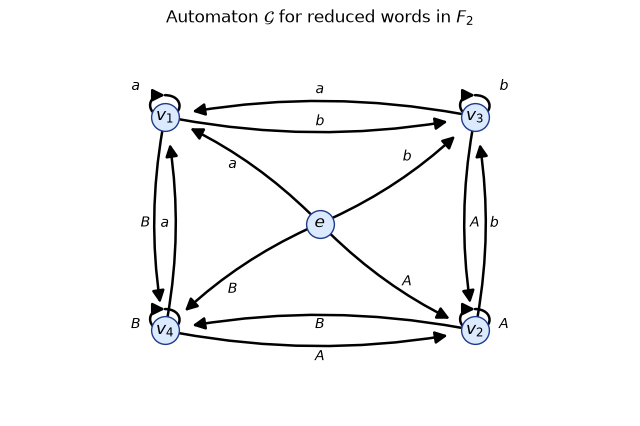

In [3]:
# --- Block 1: Fixed layout for deterministic figure geometry ---
pos = {
    'e': (2.0, 0.0),
    'v_1': (1.2, 1.0),
    'v_2': (2.8, -1.0),
    'v_3': (2.8, 1.0),
    'v_4': (1.2, -1.0),
}

# --- Block 2: Draw automaton and generator labels ---
plt.figure()
nx.draw_networkx_nodes(G, pos, node_color='#dbeafe', edgecolors='#1e3a8a', node_size=400)
node_labels = {'e': r'$e$', 'v_1': r'$v_1$', 'v_2': r'$v_2$', 'v_3': r'$v_3$', 'v_4': r'$v_4$'}
nx.draw_networkx_labels(G, pos, labels=node_labels, font_weight='bold')
# Draw non-loop edges and self-loops separately.
non_loop_edges = [(u, v) for (u, v) in G.edges() if u != v]
loop_edges = [(u, v) for (u, v) in G.edges() if u == v]

nx.draw_networkx_edges(
    G, pos, edgelist=non_loop_edges,
    arrows=True, arrowstyle='-|>', arrowsize=18, width=1.8,
    min_source_margin=10, min_target_margin=20,
    connectionstyle='arc3,rad=0.10'
)

# Longer self-loops.
nx.draw_networkx_edges(
    G, pos, edgelist=loop_edges,
    arrows=True, arrowstyle='-|>', arrowsize=18, width=1.8,
    min_source_margin=10, min_target_margin=20,
    connectionstyle='arc3,rad=0.70'
)


# Explicit labels for all directed non-loop edges.
manual_edge_labels = {
    ('e', 'v_1'): (1.55, 0.55, r'$a$'),
    ('e', 'v_2'): (2.45, -0.55, r'$A$'),
    ('e', 'v_3'): (2.45, 0.62, r'$b$'),
    ('e', 'v_4'): (1.55, -0.62, r'$B$'),

    ('v_1', 'v_1'): (1.05, 1.28, r'$a$'),
    ('v_1', 'v_3'): (2.00, 0.95, r'$b$'),
    ('v_1', 'v_4'): (1.1, 0.00, r'$B$'),

    ('v_2', 'v_2'): (2.95, -0.95, r'$A$'),
    ('v_2', 'v_3'): (2.90, 0.00, r'$b$'),
    ('v_2', 'v_4'): (2.00, -0.95, r'$B$'),

    ('v_3', 'v_1'): (2.00, 1.25, r'$a$'),
    ('v_3', 'v_2'): (2.8, -0.00, r'$A$'),
    ('v_3', 'v_3'): (2.95, 1.28, r'$b$'),

    ('v_4', 'v_1'): (1.2, 0.00, r'$a$'),
    ('v_4', 'v_2'): (2.00, -1.25, r'$A$'),
    ('v_4', 'v_4'): (1.05, -0.95, r'$B$'),
}

for (u, v), (x, y, lbl) in manual_edge_labels.items():
    if G.has_edge(u, v):
        plt.text(x, y, lbl, fontsize=10, ha='center', va='center')

plt.title(r'Automaton $\mathcal{G}$ for reduced words in $F_2$')
plt.xlim(0.4, 3.6)
plt.ylim(-1.8, 1.8)
plt.axis('off')
plt.show()


## 2) Build $C(\mathcal G)$ (component graph) and draw digraph

Strongly connected components: [{'v_3', 'v_2', 'v_4', 'v_1'}, {'e'}]
Number of components in C(G): 2
Edges of C(G): [(1, 0)]


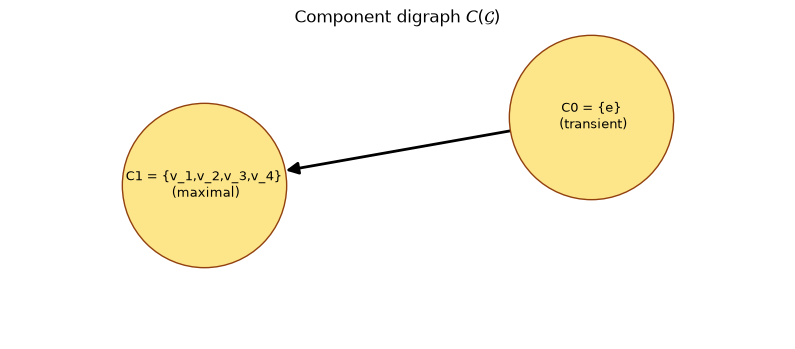

In [4]:
# --- Block 1: Compute SCCs and condensation graph C(G) ---
scc = list(nx.strongly_connected_components(G))
C = nx.condensation(G, scc=scc)

# --- Block 2: Human-readable component labels ---
comp_label = {}
for i, comp in enumerate(scc):
    if 'e' in comp:
        comp_label[i] = 'C0 = {e}\n (transient)'
    else:
        comp_label[i] = 'C1 = {v_1,v_2,v_3,v_4}\n (maximal)'

print('Strongly connected components:', scc)
print('Number of components in C(G):', C.number_of_nodes())
print('Edges of C(G):', list(C.edges()))

# --- Block 3: Draw component graph ---
plt.figure(figsize=(10, 4))
posC = {0: (0.0, 0.0), 1: (2.8, 0.4)}
nx.draw_networkx_nodes(C, posC, node_color='#fde68a', edgecolors='#92400e', node_size=14000)
nx.draw_networkx_labels(C, posC, labels=comp_label, font_size=9)
nx.draw_networkx_edges(C, posC, arrows=True, arrowstyle='-|>', arrowsize=18, width=2, min_source_margin=20, min_target_margin=60)
plt.title(r'Component digraph $C(\mathcal{G})$')
plt.xlim(-1.4, 4.2)
plt.ylim(-0.9, 0.9)
plt.axis('off')
plt.show()


## 3) Compute $M$, $M_C$, maximal eigenvalues, $N$, and $\mu_p$

In [5]:
# --- Block 1: Restrict M to maximal recurrent component ---
states_C = ['v_1', 'v_2', 'v_3', 'v_4']
M_C = nx.to_numpy_array(G, nodelist=states_C, dtype=int)

# --- Block 2: Compare spectra of M and M_C ---
eig_M = np.linalg.eigvals(M.astype(float))
eig_MC = np.linalg.eigvals(M_C.astype(float))
lambda_M = np.max(np.abs(eig_M))
lambda_MC = np.max(np.abs(eig_MC))

print('M (5x5) in order', states)
print(M)
print('\nM_C (4x4) in order', states_C)
print(M_C)
print('\nEigenvalues of M:', eig_M)
print('Eigenvalues of M_C:', eig_MC)
print('Maximal eigenvalue |lambda(M)| =', lambda_M)
print('Maximal eigenvalue |lambda(M_C)| =', lambda_MC)


M (5x5) in order ['e', 'v_1', 'v_2', 'v_3', 'v_4']
[[0 1 1 1 1]
 [0 1 0 1 1]
 [0 0 1 1 1]
 [0 1 1 1 0]
 [0 1 1 0 1]]

M_C (4x4) in order ['v_1', 'v_2', 'v_3', 'v_4']
[[1 0 1 1]
 [0 1 1 1]
 [1 1 1 0]
 [1 1 0 1]]

Eigenvalues of M: [ 0.+0.j  3.+0.j  1.+0.j -1.+0.j  1.+0.j]
Eigenvalues of M_C: [ 3.+0.j  1.+0.j -1.+0.j  1.+0.j]
Maximal eigenvalue |lambda(M)| = 2.9999999999999964
Maximal eigenvalue |lambda(M_C)| = 2.9999999999999964


In [6]:
def pf_right(A):
    """Return (PF eigenvalue, normalized nonnegative right PF vector)."""
    vals, vecs = np.linalg.eig(A)
    k = int(np.argmax(np.abs(vals)))
    lam = float(np.real(vals[k]))
    v = np.real(vecs[:, k])
    # orient and normalize for readability
    if v.sum() < 0:
        v = -v
    v = np.abs(v)
    v = v / v.sum()
    return lam, v

# Right PF vector for M and left PF vector via M^T.
lam, r = pf_right(M.astype(float))
_lam_left, l = pf_right(M.T.astype(float))

print('lambda =', lam)
print('Right PF vector r (normalized sum=1):')
for s, x in zip(states, r):
    print(f'  r[{s}] = {x:.10f}')

print('\nLeft PF vector l (normalized sum=1):')
for s, x in zip(states, l):
    print(f'  l[{s}] = {x:.10f}')

lambda = 2.9999999999999964
Right PF vector r (normalized sum=1):
  r[e] = 0.2500000000
  r[v_1] = 0.1875000000
  r[v_2] = 0.1875000000
  r[v_3] = 0.1875000000
  r[v_4] = 0.1875000000

Left PF vector l (normalized sum=1):
  l[e] = 0.0000000000
  l[v_1] = 0.2500000000
  l[v_2] = 0.2500000000
  l[v_3] = 0.2500000000
  l[v_4] = 0.2500000000


In [7]:
# N_{pq} = M_{pq} r_q / (lambda r_p), with paper convention on zero r_p.
# This normalizes M into a stochastic matrix on active states.
N = np.zeros_like(M, dtype=float)
eps = 1e-14
for p in range(len(states)):
    if r[p] > eps:
        for q in range(len(states)):
            N[p, q] = M[p, q] * r[q] / (lam * r[p])
    else:
        N[p, p] = 1.0

print('N matrix:')
print(N)
print('\nRow sums of N:')
print(N.sum(axis=1))

N matrix:
[[0.       0.25     0.25     0.25     0.25    ]
 [0.       0.333333 0.       0.333333 0.333333]
 [0.       0.       0.333333 0.333333 0.333333]
 [0.       0.333333 0.333333 0.333333 0.      ]
 [0.       0.333333 0.333333 0.       0.333333]]

Row sums of N:
[1. 1. 1. 1. 1.]


In [8]:
def cesaro_projection(A, lam, v, n_terms=3000):
    """Approximate Cesaro limit (1/n) sum_{i=0}^{n-1} lam^{-i} A^i v."""
    # Stable recurrence: y_i = lam^{-i} A^i v, so y_{i+1} = (A/lam) y_i.
    y = v.astype(float).copy()
    acc = np.zeros_like(y)
    for _ in range(n_terms):
        acc += y
        y = (A @ y) / lam
    return acc / n_terms

# Vectors from the paper notation.
v_u = np.ones(len(states), dtype=float)        # uniform vector
v_i = np.zeros(len(states), dtype=float)       # initial-state indicator
v_i[idx['e']] = 1.0

r_vu = cesaro_projection(M.astype(float), lam, v_u)
l_vi = cesaro_projection(M.T.astype(float), lam, v_i)

raw_mu = r_vu * l_vi
den = raw_mu.sum()

# Primary formula: mu_p proportional to r(v_u)_p * l(v_i)_p.
if den > 0:
    mu = raw_mu / den
    mu_note = 'mu from r(v_u) * l(v_i) (paper-style expression).'
else:
    # In this F2 model, e is transient, so l(v_i) can project to 0.
    # Fallback keeps the same stationary-state interpretation via PF product r*l.
    raw_mu_pf = r * l
    mu = raw_mu_pf / raw_mu_pf.sum()
    mu_note = 'r(v_u)*l(v_i) was degenerate (sum=0); using PF product r*l normalized.'

print('r(v_u):', r_vu)
print('l(v_i):', l_vi)
print('raw product r(v_u)*l(v_i):', raw_mu)
print('sum(raw_mu) =', den)
print(mu_note)

print('\nmu_p by state order', states)
for s, x in zip(states, mu):
    print(f'  mu[{s}] = {x:.10f}')

r(v_u): [1.333222 1.       1.       1.       1.      ]
l(v_i): [0.000333 0.333222 0.333222 0.333222 0.333222]
raw product r(v_u)*l(v_i): [0.000444 0.333222 0.333222 0.333222 0.333222]
sum(raw_mu) = 1.3333332963013285
mu from r(v_u) * l(v_i) (paper-style expression).

mu_p by state order ['e', 'v_1', 'v_2', 'v_3', 'v_4']
  mu[e] = 0.0003333056
  mu[v_1] = 0.2499166736
  mu[v_2] = 0.2499166736
  mu[v_3] = 0.2499166736
  mu[v_4] = 0.2499166736


In [9]:
def path_measure_states(state_path, mu_vec, N_mat, state_index):
    """
    Return mu(path) = mu(v0) * prod_i N_{v_i, v_{i+1}} for a state path.

    state_path: list/tuple of state labels, e.g. ['v_1','v_3','v_4']
    """
    if len(state_path) == 0:
        raise ValueError('state_path must contain at least one state label')

    try:
        i0 = state_index[state_path[0]]
    except KeyError as exc:
        raise ValueError(f'Unknown state label in state_path: {exc}') from exc

    val = float(mu_vec[i0])
    for u, v in zip(state_path[:-1], state_path[1:]):
        try:
            iu = state_index[u]
            iv = state_index[v]
        except KeyError as exc:
            raise ValueError(f'Unknown state label in state_path: {exc}') from exc
        val *= float(N_mat[iu, iv])
    return val


def word_to_state_path(word, start='e'):
    """
    Convert a generator word (letters in {'a','A','b','B'}) to the induced state path.
    The returned state path does not include the initial state e.
    """
    if start != 'e':
        raise ValueError("This notebook expects words to be read from start state 'e'.")

    cur = start
    state_path = []
    for g in word:
        # Find the unique labeled transition cur --g--> next_state.
        candidates = [v for gen, v in transitions[cur] if gen == g]
        if len(candidates) != 1:
            raise ValueError(
                f"Word is not reduced/allowed at step {cur} --{g}--> ?"
            )
        nxt = candidates[0]
        state_path.append(nxt)
        cur = nxt

    return state_path


def path_measure_word(word, mu_vec, N_mat, state_index, start='e'):
    """Compute path measure directly from a generator word."""
    state_path = word_to_state_path(word, start=start)
    return path_measure_states(state_path, mu_vec, N_mat, state_index)


In [10]:
# Example with a generator word
word_0 = ['a', 'B']
print('word_0 =', word_0)
try:
    print('state_path_0 =', word_to_state_path(word_0))
    print('mu(word_0) =', path_measure_word(word_0, mu, N, idx))
    print('reference measure = 1/4 * 1/3 =', 1/4 * 1/3)
except ValueError as exc:
    print('Expected invalid example:', exc)


word_0 = ['a', 'B']
state_path_0 = ['v_1', 'v_4']
mu(word_0) = 0.08330555786959902
reference measure = 1/4 * 1/3 = 0.08333333333333333


In [11]:
# Another example with a generator word
word_1 = ['a', 'B', 'A', 'B']
state_path_1 = word_to_state_path(word_1)
print('word_1 =', word_1)
print('state_path_1 =', state_path_1)
print('mu(word_1) =', path_measure_word(word_1, mu, N, idx))
print('reference measure = 1/4 * 1/3 * 1/3 * 1/3=', 1/4 * 1/3 * 1/3 * 1/3)

word_1 = ['a', 'B', 'A', 'B']
state_path_1 = ['v_1', 'v_4', 'v_2', 'v_4']
mu(word_1) = 0.009256173096622135
reference measure = 1/4 * 1/3 * 1/3 * 1/3= 0.009259259259259259


In [12]:
word_1 = ['a', 'a', 'b']
word_2 = ['a', 'B', 'A']

print('word_1 =', word_1)
print('state path 1 =', word_to_state_path(word_1))
print('mu(word_1) =', path_measure_word(word_1, mu, N, idx))

print('word_2 =', word_2)
print('state path 2 =', word_to_state_path(word_2))
print('mu(word_2) =', path_measure_word(word_2, mu, N, idx))


word_1 = ['a', 'a', 'b']
state path 1 = ['v_1', 'v_1', 'v_3']
mu(word_1) = 0.027768519289866365
word_2 = ['a', 'B', 'A']
state path 2 = ['v_1', 'v_4', 'v_2']
mu(word_2) = 0.027768519289866372


## 4) Helper functions and empirical checks

Reusable diagnostics for reduced words, periodicity, and ordered frequencies.


In [13]:
from math import gcd
import random

inverse_letter = {'a': 'A', 'A': 'a', 'b': 'B', 'B': 'b'}

def is_reduced_word(word):
    """Check reducedness: no adjacent inverse pair aA, Aa, bB, or Bb."""
    w = list(word)
    for u, v in zip(w[:-1], w[1:]):
        if inverse_letter.get(u) == v:
            return False
    return True

def assert_reduced_word(word, name='word'):
    if not is_reduced_word(word):
        raise ValueError(
            f"{name} is not reduced: found adjacent inverse pair in {list(word)}"
        )

def markov_period(P, tol=1e-12, max_power=256):
    """
    Compute period information for a finite Markov chain with transition matrix P.
    Returns (period_by_state, lcm_period_of_recurrent_classes).
    """
    P = np.asarray(P, dtype=float)
    n = P.shape[0]
    support = (P > tol).astype(int)
    Gp = nx.DiGraph(support)

    periods = {i: 0 for i in range(n)}
    # Find recurrent classes as SCCs with no outgoing edges.
    sccs = list(nx.strongly_connected_components(Gp))
    recurrent_classes = []
    for comp in sccs:
        has_out = any((u in comp and v not in comp) for (u, v) in Gp.edges())
        if not has_out:
            recurrent_classes.append(comp)

    def period_for_state(i):
        g = 0
        A = np.eye(n)
        for k in range(1, max_power + 1):
            A = A @ P
            if A[i, i] > tol:
                g = k if g == 0 else gcd(g, k)
            if g == 1:
                break
        return g

    for comp in recurrent_classes:
        rep = next(iter(comp))
        d = period_for_state(rep)
        for i in comp:
            periods[i] = d

    # States not in recurrent classes keep period 0 (transient / not computed).
    lcm_period = 1
    for d in set(periods.values()):
        if d > 0:
            lcm_period = lcm_period * d // gcd(lcm_period, d)

    return periods, lcm_period

def random_geodesic_ray(n, transitions, start='e', seed=None, return_states=False):
    """
    Generate a random geodesic word ray sigma of length n.
    Output is a list of letters (states excluding the start state).
    """
    if seed is not None:
        random.seed(seed)
    cur = start
    state_path = [cur]
    word = []
    for _ in range(n):
        gen, nxt = random.choice(transitions[cur])
        state_path.append(nxt)
        word.append(gen)
        cur = nxt
    # By construction through transitions, `word` is reduced/geodesic.
    if return_states:
        return word, state_path
    return word

def ordered_frequency(word_w, sigma):
    """
    Finite-length ordered frequency approximation for f_w(sigma).
    word_w: list/tuple, e.g. ['a','b','A','b']
    sigma: list/tuple geodesic word ray letters

    Uses disjoint blocks of size |w| starting at position 0, as in the definition.
    Returns dict with count, num_blocks, and frequency.
    """
    w = list(word_w)
    s = list(sigma)
    assert_reduced_word(w, name='word_w')
    assert_reduced_word(s, name='sigma')
    k = len(w)
    if k == 0:
        raise ValueError('word_w must be non-empty')
    num_blocks = len(s) // k
    if num_blocks == 0:
        return {'count': 0, 'num_blocks': 0, 'frequency': 0.0}
    cnt = 0
    for i in range(num_blocks):
        block = s[i*k:(i+1)*k]
        if block == w:
            cnt += 1
    return {'count': cnt, 'num_blocks': num_blocks, 'frequency': cnt / num_blocks}


In [14]:
# --- Quick examples: reducedness, period, and ordered frequencies ---
print(['a', 'A'], is_reduced_word(['a','A']))

periods, d_lcm = markov_period(N)
print('period by state index:', periods)
print('LCM period of recurrent classes:', d_lcm)

sigma = random_geodesic_ray(100000, transitions)
w_0 = ['a', 'b', 'A', 'B']
w_1 = ['a','a']
print('ordered frequency data for w_0:', ordered_frequency(w_0, sigma))
print('ordered frequency data for w_1:', ordered_frequency(w_1, sigma))


['a', 'A'] False
period by state index: {0: 0, 1: 1, 2: 1, 3: 1, 4: 1}
LCM period of recurrent classes: 1
ordered frequency data for w_0: {'count': 230, 'num_blocks': 25000, 'frequency': 0.0092}
ordered frequency data for w_1: {'count': 4267, 'num_blocks': 50000, 'frequency': 0.08534}


### Notes
- This is the canonical reduced-word automaton for $F_2$ with 5 states.
- If your hand-drawn automata uses a different 5-state model, we can replace `transitions` and regenerate all outputs.
- If your $M_C$ is defined as the transition matrix on the *maximal component of directed edges* (rather than states), that gives a different size; send your matrix order and we can match it exactly.